# Part 4: Bacteria and Nutrients 

Water quality monitoring has included temperature and dissolved oxygen (DO), but there was another sampling effort to test the water for potentially harmful bacteria and nutrients. In this data, we have the same monitoring sites, collection times, and values for each sample, including turbidity. Bacteria include total coliforms and E.coli, and nutrients include nitrates and phosphates. This pages steps through summarizing this data, checking it for values above clean water thresholds, and visualizing it with different categories. 

Data science topics covered in part 4 include:
- dataframe manipulation: `mutate()`, `select()`, `inner_join()`, `pivot_longer()` 
- summarizing data by categories using `group_by()` and `summarize()`
- another application of `ifelse()` function 
- more visualization with ggplot 

In [3]:
# load necessary libraries
library(tidyverse)
library(lubridate)
library(janitor)
# make plots larger
options(repr.plot.width = 10, repr.plot.height = 8)

## Summarize bacteria and nutrient data 

The following sections read in the csv, preview it, and make a couple of changes. First the date column is converted to a date data type instead of character, and a new column `year` is created. Then all headers are converted to lower case, to make typing easier. 

After these steps are taken, the data frame is summarized by year, and combined with the previous water quality data frame and TEK summary. 

In [4]:

## read in data and check for missing data
# the document needs to be a CSV, so change the file format in Excel
bact <- read.csv("https://raw.githubusercontent.com/IndigenousEnvDataSci/IndigenousEnvDataSci.github.io/refs/heads/main/KAVI/data/K-avi_Bacteria_and_Nutrient_Data.csv")

# look at the structure of the file, see what might need to be changed
str(bact)


'data.frame':	557 obs. of  10 variables:
 $ X                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sample_location          : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ longitude                : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ latitude                 : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ date                     : chr  "1/15/90" "2/1/90" "3/15/90" "4/12/90" ...
 $ E.coli.col.100.mL        : int  NA NA NA NA NA 151 152 152 NA NA ...
 $ Total.Coliform.col.100.mL: int  NA NA NA NA NA 322 330 300 NA NA ...
 $ Nitrates.mg.L            : num  NA NA NA NA NA 14.9 15.2 15 NA NA ...
 $ Phos.mg.L                : num  NA NA NA NA NA 0.14 0.15 0.13 NA NA ...
 $ Turbidity.ntu            : int  NA NA NA NA NA 41 43 42 NA NA ...


In [5]:
# most data were formatted correctly, we just have to fix problems with the date
bact$date <- as.Date(bact$date, format = "%m/%d/%y")

# create a column that's specific to the year
bact$year <- year(bact$date)

# rerun the structure function, to know that it worked
str(bact)

# clean headers 
colnames(bact) <- tolower(colnames(bact))

'data.frame':	557 obs. of  11 variables:
 $ X                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sample_location          : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ longitude                : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ latitude                 : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ date                     : Date, format: "1990-01-15" "1990-02-01" ...
 $ E.coli.col.100.mL        : int  NA NA NA NA NA 151 152 152 NA NA ...
 $ Total.Coliform.col.100.mL: int  NA NA NA NA NA 322 330 300 NA NA ...
 $ Nitrates.mg.L            : num  NA NA NA NA NA 14.9 15.2 15 NA NA ...
 $ Phos.mg.L                : num  NA NA NA NA NA 0.14 0.15 0.13 NA NA ...
 $ Turbidity.ntu            : int  NA NA NA NA NA 41 43 42 NA NA ...
 $ year                     : num  1990 1990 1990 1990 1990 1990 1990 1990 1990 1990 ...


In [6]:
## now we can start summarizing the data, we'll look at it on an annual level
bact_sum <- bact %>%
  group_by(sample_location, year) %>% # you can group by multiple or a single group(s) to make this summary
  summarize_at(vars(e.coli.col.100.ml, total.coliform.col.100.ml, phos.mg.l, nitrates.mg.l, turbidity.ntu),
               list(mean=mean, median=median, min=min, max=max), na.rm=T)

head(bact_sum)

Warning message:
"There were 50 warnings in `summarise()`.
The first warning was:
ℹ In argument: `e.coli.col.100.ml_min = .Primitive("min")(e.coli.col.100.ml, na.rm = TRUE)`.
ℹ In group 17: `sample_location = "Monitoring Site 2"` `year = 1995`.
Caused by warning:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 49 remaining warnings."


sample_location,year,e.coli.col.100.ml_mean,total.coliform.col.100.ml_mean,phos.mg.l_mean,nitrates.mg.l_mean,turbidity.ntu_mean,e.coli.col.100.ml_median,total.coliform.col.100.ml_median,phos.mg.l_median,⋯,e.coli.col.100.ml_min,total.coliform.col.100.ml_min,phos.mg.l_min,nitrates.mg.l_min,turbidity.ntu_min,e.coli.col.100.ml_max,total.coliform.col.100.ml_max,phos.mg.l_max,nitrates.mg.l_max,turbidity.ntu_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,1990,151.6667,317.3333,0.1400000,15.03333,42.00000,152,322,0.140,⋯,151,300,0.13,14.9,41,152,330,0.15,15.2,43
Monitoring Site 1,1991,151.6667,317.3333,0.1400000,15.03333,42.00000,152,322,0.140,⋯,151,300,0.13,14.9,41,152,330,0.15,15.2,43
Monitoring Site 1,1992,153.0000,317.3333,0.1583333,15.33333,43.33333,153,321,0.155,⋯,152,299,0.15,14.7,42,154,332,0.17,16.0,45
Monitoring Site 1,1993,153.0000,317.3333,0.1583333,15.33333,43.33333,153,321,0.155,⋯,152,299,0.15,14.7,42,154,332,0.17,16.0,45
Monitoring Site 1,1994,149.3333,285.6667,0.1233333,13.96667,39.33333,149,285,0.120,⋯,148,273,0.10,13.4,39,151,299,0.15,14.3,40
Monitoring Site 1,1995,149.3333,285.6667,0.1233333,13.96667,39.33333,149,285,0.120,⋯,148,273,0.10,13.4,39,151,299,0.15,14.3,40


With the summary of the bacteria and nutrient data, we can join to the other water quality dataset, using `full_join()`

In [7]:
# read in cleaned water quality dataset
water <- read.csv("https://raw.githubusercontent.com/IndigenousEnvDataSci/IndigenousEnvDataSci.github.io/refs/heads/main/KAVI/data/K-avi_tribe_water_quality_dataset_clean.csv")

# remove the line number (X), column
water <- water[,-1]

# edit water 
water_ann <- water %>% 
    mutate(date = ymd(date),
           year = year(date)) %>% 
    group_by(sample_location, year) %>% 
    summarize_at(vars(DO, water_temp_C, specific_conductivity, discharge),
               list(mean=mean, median=median, min=min, max=max), na.rm=T)

head(water_ann)


Warning message:
"There were 22 warnings in `summarise()`.
The first warning was:
ℹ In argument: `discharge_min = .Primitive("min")(discharge, na.rm = TRUE)`.
ℹ In group 34: `sample_location = "Monitoring Site 4"` `year = 1990`.
Caused by warning:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 21 remaining warnings."


sample_location,year,DO_mean,water_temp_C_mean,specific_conductivity_mean,discharge_mean,DO_median,water_temp_C_median,specific_conductivity_median,discharge_median,DO_min,water_temp_C_min,specific_conductivity_min,discharge_min,DO_max,water_temp_C_max,specific_conductivity_max,discharge_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,1990,11.03333,4.658333,100.1667,74.16667,11.80,3.550,87,39.0,7.8,0.30,78,20,12.3,15.0,180,261
Monitoring Site 1,1991,11.01667,4.750000,99.0000,73.66667,11.90,3.600,86,39.5,7.2,0.30,75,20,12.3,15.2,175,260
Monitoring Site 1,1992,10.95000,4.820000,101.0833,74.91667,11.85,3.650,89,39.0,7.1,0.35,76,20,12.3,15.5,182,265
Monitoring Site 1,1993,10.71667,4.939167,103.6667,70.75000,11.60,3.725,91,35.0,7.0,0.37,80,19,12.0,15.6,185,260
Monitoring Site 1,1994,10.46667,4.697500,103.6667,75.91667,11.30,2.750,91,41.5,6.9,0.40,80,18,11.8,15.8,185,250
Monitoring Site 1,1995,17.99583,5.245833,102.9167,77.16667,11.00,4.050,90,39.0,6.5,0.60,80,20,105.0,16.0,180,275


Note that when we read in the `water` data frame, the `date` column is stored as a character. To be able to join with `bact` data frame, it needs to be the same data type, so we first convert it. Same as the summary data frame above, we group by the sample location and year to get the summaries of each. 

In [8]:
# now we can try again to join them
water_bact_join <- full_join(water_ann, bact_sum) 
# this function is great, because it is telling us all the information it is joining by!

head(water_bact_join)

Joining with `by = join_by(sample_location, year)`


sample_location,year,DO_mean,water_temp_C_mean,specific_conductivity_mean,discharge_mean,DO_median,water_temp_C_median,specific_conductivity_median,discharge_median,⋯,e.coli.col.100.ml_min,total.coliform.col.100.ml_min,phos.mg.l_min,nitrates.mg.l_min,turbidity.ntu_min,e.coli.col.100.ml_max,total.coliform.col.100.ml_max,phos.mg.l_max,nitrates.mg.l_max,turbidity.ntu_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,1990,11.03333,4.658333,100.1667,74.16667,11.80,3.550,87,39.0,⋯,151,300,0.13,14.9,41,152,330,0.15,15.2,43
Monitoring Site 1,1991,11.01667,4.750000,99.0000,73.66667,11.90,3.600,86,39.5,⋯,151,300,0.13,14.9,41,152,330,0.15,15.2,43
Monitoring Site 1,1992,10.95000,4.820000,101.0833,74.91667,11.85,3.650,89,39.0,⋯,152,299,0.15,14.7,42,154,332,0.17,16.0,45
Monitoring Site 1,1993,10.71667,4.939167,103.6667,70.75000,11.60,3.725,91,35.0,⋯,152,299,0.15,14.7,42,154,332,0.17,16.0,45
Monitoring Site 1,1994,10.46667,4.697500,103.6667,75.91667,11.30,2.750,91,41.5,⋯,148,273,0.10,13.4,39,151,299,0.15,14.3,40
Monitoring Site 1,1995,17.99583,5.245833,102.9167,77.16667,11.00,4.050,90,39.0,⋯,148,273,0.10,13.4,39,151,299,0.15,14.3,40


## Join to TEK summary dataset


In [9]:
# read in the TEK summary dataset so we know what we're working with
tek_sum <- read.csv("https://raw.githubusercontent.com/IndigenousEnvDataSci/IndigenousEnvDataSci.github.io/refs/heads/main/KAVI/data/tek_summary.csv")

# it can be helpful to know what our column names are when we're summarizing
# data, so try this to have a list
names(water_bact_join)

# now we need to summarize the water quality dataset so that we can have them
# in the same format to merge them together
water_bact_sum <- water_bact_join %>%
  group_by(sample_location) %>%
  # find the mean for all of the different water quality metrics at all years 
  summarise(mean_DO = mean(DO_mean),
            mean_temp = mean(water_temp_C_mean),
            mean_sc = mean(specific_conductivity_mean),
            mean_ecoli = mean(e.coli.col.100.ml_mean, na.rm = T),
            mean_tot_col = mean(total.coliform.col.100.ml_mean, na.rm = T),
            mean_nit = mean(nitrates.mg.l_mean, na.rm = T),
            mean_phos = mean(phos.mg.l_mean, na.rm = T),
            mean_turb = mean(turbidity.ntu_mean, na.rm = T))

# join data 
water_bact_tek <- inner_join(water_bact_sum, tek_sum)

# preview new data frame 
str(water_bact_tek)


[1] "sample_location"                  "year"                            
 [3] "DO_mean"                          "water_temp_C_mean"               
 [5] "specific_conductivity_mean"       "discharge_mean"                  
 [7] "DO_median"                        "water_temp_C_median"             
 [9] "specific_conductivity_median"     "discharge_median"                
[11] "DO_min"                           "water_temp_C_min"                
[13] "specific_conductivity_min"        "discharge_min"                   
[15] "DO_max"                           "water_temp_C_max"                
[17] "specific_conductivity_max"        "discharge_max"                   
[19] "e.coli.col.100.ml_mean"           "total.coliform.col.100.ml_mean"  
[21] "phos.mg.l_mean"                   "nitrates.mg.l_mean"              
[23] "turbidity.ntu_mean"               "e.coli.col.100.ml_median"        
[25] "total.coliform.col.100.ml_median" "phos.mg.l_median"                
[27] "nitrates.mg.l_median"             "turbidity.ntu_median"            
[29] "e.coli.col.100.ml_min"            "total.coliform.col.100.ml_min"   
[31] "phos.mg.l_min"                    "nitrates.mg.l_min"               
[33] "turbidity.ntu_min"                "e.coli.col.100.ml_max"           
[35] "total.coliform.col.100.ml_max"    "phos.mg.l_max"                   
[37] "nitrates.mg.l_max"                "turbidity.ntu_max"

Joining with `by = join_by(sample_location)`


tibble [5 × 15] (S3: tbl_df/tbl/data.frame)
 $ sample_location: chr [1:5] "Monitoring Site 1" "Monitoring Site 2" "Monitoring Site 3" "Monitoring Site 4" ...
 $ mean_DO        : num [1:5] 11.17 9.78 10.69 10.31 11.12
 $ mean_temp      : num [1:5] 5.15 9.01 9.6 9.21 6.18
 $ mean_sc        : num [1:5] 101.2 149 259.6 124.7 40.8
 $ mean_ecoli     : num [1:5] 152.5 166.1 141.2 53.5 22.4
 $ mean_tot_col   : num [1:5] 307.9 266.1 235.9 88.7 51.9
 $ mean_nit       : num [1:5] 13.28 15.77 12.46 3.52 1.38
 $ mean_phos      : num [1:5] 0.1294 0.21 0.153 0.0306 0.02
 $ mean_turb      : num [1:5] 41.27 56.67 47.7 5.24 2.79
 $ X              : int [1:5] 1 5 3 2 4
 $ site           : chr [1:5] "Ceremony.Site" "Medicinal.Food.Site" "Hunting.Grounds" "Fishing.Site" ...
 $ mean_tek       : num [1:5] 2 3.75 2.25 4.5 2.5
 $ sd             : num [1:5] 0 0.957 1.5 1 1.732
 $ n              : int [1:5] 4 4 4 4 4
 $ se_tek         : num [1:5] 0 0.479 0.75 0.5 0.866


💻**Your turn!**

How might we want to visualize this combined dataframe?

Make a plot here with ggplot that includes: the TEK rank, the monitoring site, and the mean nitrates. Then pick another variable from the combined data to visualize. 


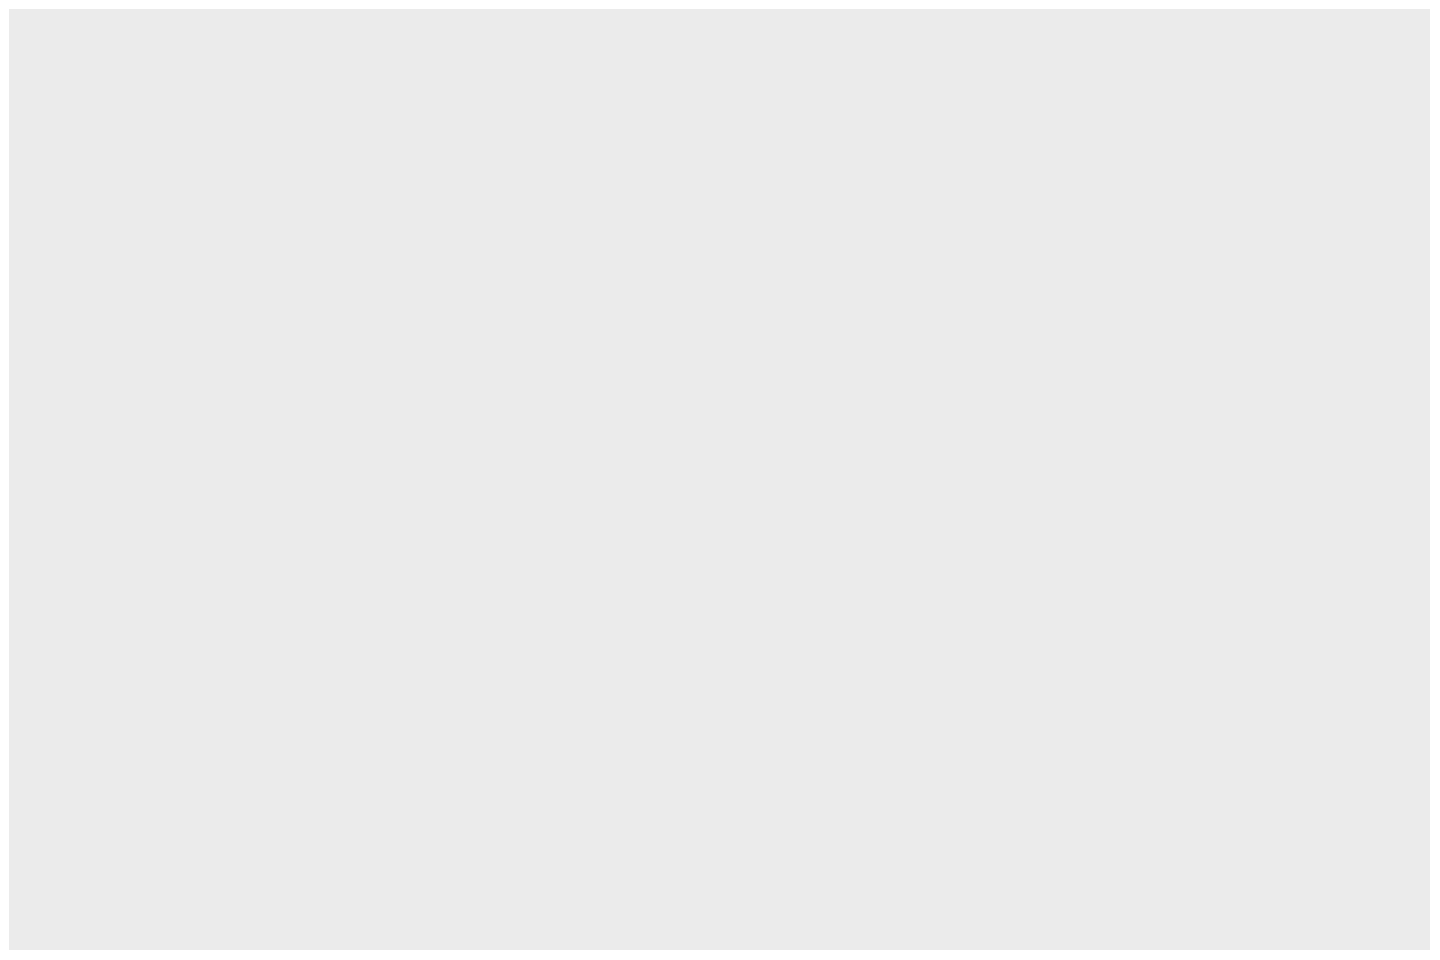

In [27]:
# your turn! make a plot 
# remember to fill in x, y, and add a geom

ggplot(water_bact_tek, aes())


##  Bacteria and Nutrient safety checks

From the bacteria and nutrient data we have four variables that tell us more about the water quality, and whether there could be harmful effects on people and the ecosystem. Because we have multiple samples for each variable, we want to know how often the measurement surpasses a potentially harmful threshold. 

These include: 

- E. Coli (`e.coli.col.100.ml`) - fecal coliform bacteria, indicator of human and animal waste contamination. Prescence could cause illness, and a greater harm for young people, elderly, and immuno-comprimised people. For recreational waters, it's recommended that e. coli doesn't surpass 126cfu/100mL ([EPA E. coli parameter factsheet](https://www.epa.gov/awma/e-coli-parameter-factsheet))
- Total Coliform (`total.coliform.col.100.ml`) - coliforms are common bacteria found in the environment, and total coliform is an indicator whether potentially harmful bacteria are present. Natural waters will typically contain some level of coliform bacteria, but here we check for 250cfu/100mL based on previously recommended criteria from the EPA. 
- Nitrates (`nitrates.mg.l`) - naturally occurring but can contaminate water from agricultural runoff and industrial waste. It should be monitored in drinking water due to health risks for infants and pregnant people. Excessive amounts of nitrates in water contribute to eutrophication, which is harmful to aquatic ecosystems. We are checking nitrates for 10mg/L based on [EPA drinking water regulations](https://www.epa.gov/ground-water-and-drinking-water/national-primary-drinking-water-regulations).
- Phosphorus (`phos.mg.l`) - an element that naturally occurs in rocks, water, and soils, often found as phosphate. It is an essential nutrient for plants, but elevated amounts in water due to fetilizer and manure runoff, sewage leaks, and urban waste disposal can cause eutrophication in water bodies. Eutrophication causes plant and algae growth and increases toxins. Limits on phosphate loads vary by location, depending on type of water body and state or tribe. Here we are checking for 0.07mg/L, within range of the EPA's [Ecoregional nutrient criteria for rivers and streams](https://www.epa.gov/nutrientpollution/ecoregional-nutrient-criteria-rivers-and-streams).

To check which samples pass or fail the thresholds to maintain clean water, we will use the `ifelse()` function. The format of this is:

`var = ifelse(condition, value if true, value if false)` 

Where our conditions will be greater than or equal to the thresholds for each variable. For example: 

`nit_check = if_else(nitrates.mg.l >= 10, 0, 1)` - tells us that if a value in the `nitrates.mg.l` column is greater than or equal  to 10, then it fails the check and `nit_check` is set to 0. If the value is less than 10, it passes and `nit_check` is set to 1. 

We will also use the `mutate()` function to create new columns (one for each water quality metric), that checks if the metric for each measurement date passes or fails based on the K'avi water quality standards, where 1 = pass, 0 = fail.

As an example, this plot shows the nitrate amount for each monitoring site, and the red horizontal dashed line represents the threshold we want to check nitrate for. The values above the line fail the check, and values below the line pass it. In the following code we save this information as new columns in a new dataframe, `bact_check`. 

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
Warning message in geom_text(aes(x = "Monitoring Site 4", y = 10.5, label = "Nitrate limit"), :
"All aesthetics have length 1, but the data has 557 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing a single row."
Warning message:
"Removed 414 rows containing non-finite outside the scale range (`stat_boxplot()`)."


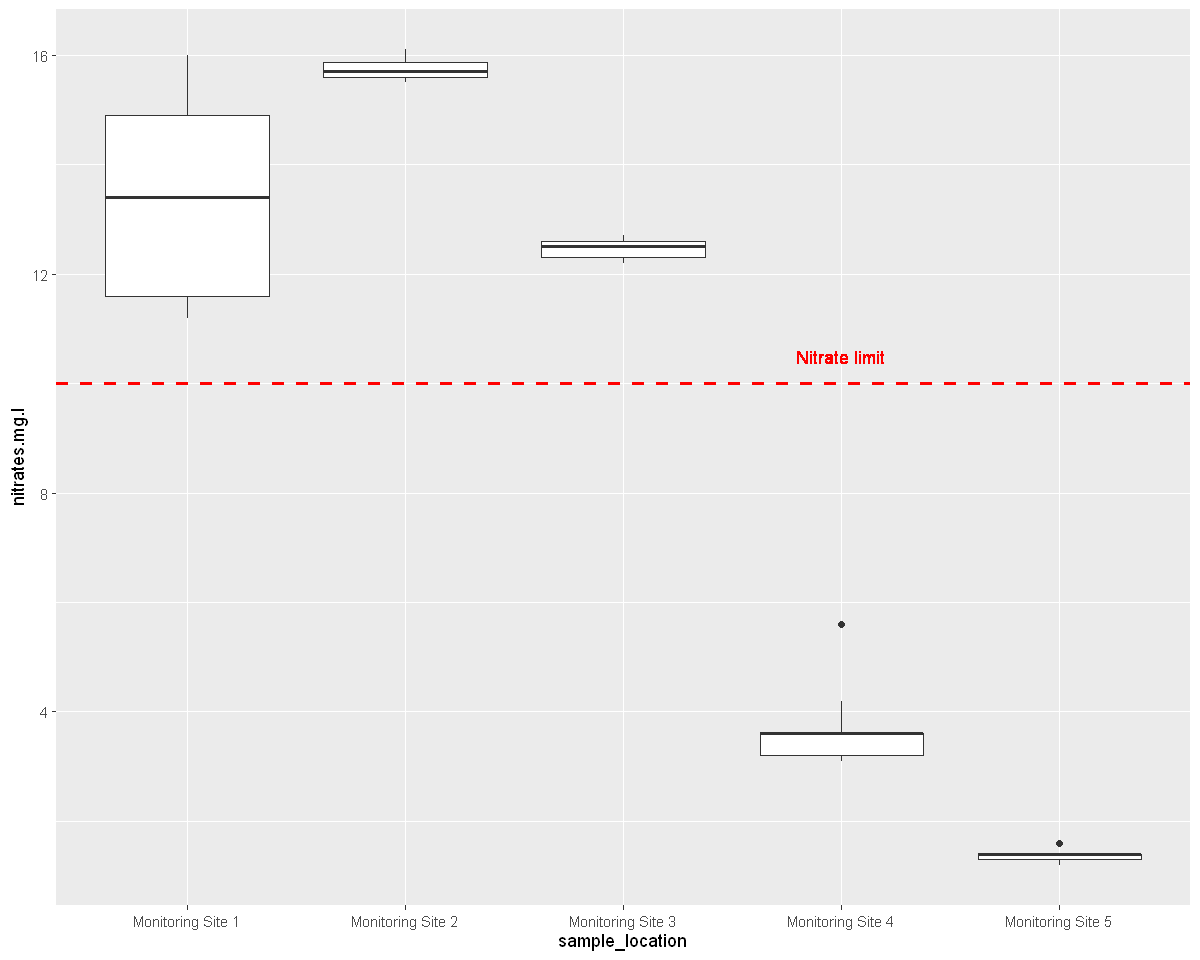

In [10]:
ggplot(bact, aes(y=nitrates.mg.l, x=sample_location)) + 
    geom_boxplot() +
    geom_hline(aes(yintercept = 10), linetype="dashed", size=1, col="red") +
    geom_text(aes(x="Monitoring Site 4", y=10.5, label="Nitrate limit"), col="red")

In [25]:
# first we pipe in our existing data frame bact 
# we use mutate to create 4 new columns, one for each variable we are checking 
bact_check <- bact %>%
  mutate(ecoli_check = if_else(e.coli.col.100.ml >= 126, 0, 1),
         tot_col_check = if_else(total.coliform.col.100.ml >= 250, 0, 1),
         nit_check = if_else(nitrates.mg.l >= 10, 0, 1),
         phos_check = if_else(phos.mg.l >= 0.07, 0, 1))

# check the count of 1 and 0 for each site using table() function 
table(bact_check$sample_location, bact_check$ecoli_check)

                   
                     0  1
  Monitoring Site 1 33  0
  Monitoring Site 2 30  0
  Monitoring Site 3 33  0
  Monitoring Site 4  0 33
  Monitoring Site 5  0 14

### Summarize the total passed checks 

Now that we know when each standard passes / fails, we can count them to figure out how often each sampling location passes based on the total number of measurements.
However, the number of total samples varies between sites, so we need to first use `add_count()` to get the number of samples for each site. 

In [26]:
rank_sum = bact_check %>% 
    filter(!is.na(ecoli_check)) %>%
    add_count(sample_location) %>%
    group_by(sample_location, n) %>%
# count the total number of times measurement 'failed' check for 
    summarise(ecoli_pass = sum(ecoli_check),
              tot_col_pass = sum(tot_col_check),
              nit_pass = sum(nit_check),
              phos_pass = sum(phos_check)) %>%
# create new column with percent of failed checks out of number of sample sizes 
    mutate(ecoli_percent = ecoli_pass/n*100,
           tot_col_percent = tot_col_pass/n*100,
           nit_percent = nit_pass/n*100,
           phos_percent = phos_pass/n*100) %>% 
    mutate(average_pass = mean(c(ecoli_percent, tot_col_percent, nit_percent, phos_percent)))

# print the output 
rank_sum 

`summarise()` has grouped output by 'sample_location'. You can override using the `.groups` argument.


sample_location,n,ecoli_pass,tot_col_pass,nit_pass,phos_pass,ecoli_percent,tot_col_percent,nit_percent,phos_percent,average_pass
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,33,0,0,0,0,0,0,0,0.0000,0.00000
Monitoring Site 2,30,0,0,0,0,0,0,0,0.0000,0.00000
Monitoring Site 3,33,0,33,0,0,0,100,0,0.0000,25.00000
Monitoring Site 4,33,33,33,33,32,100,100,100,96.9697,99.24242
Monitoring Site 5,14,14,14,14,14,100,100,100,100.0000,100.00000


### Visualize the checked data

We can compare sites by the average pass percentage, like in this column plot. 

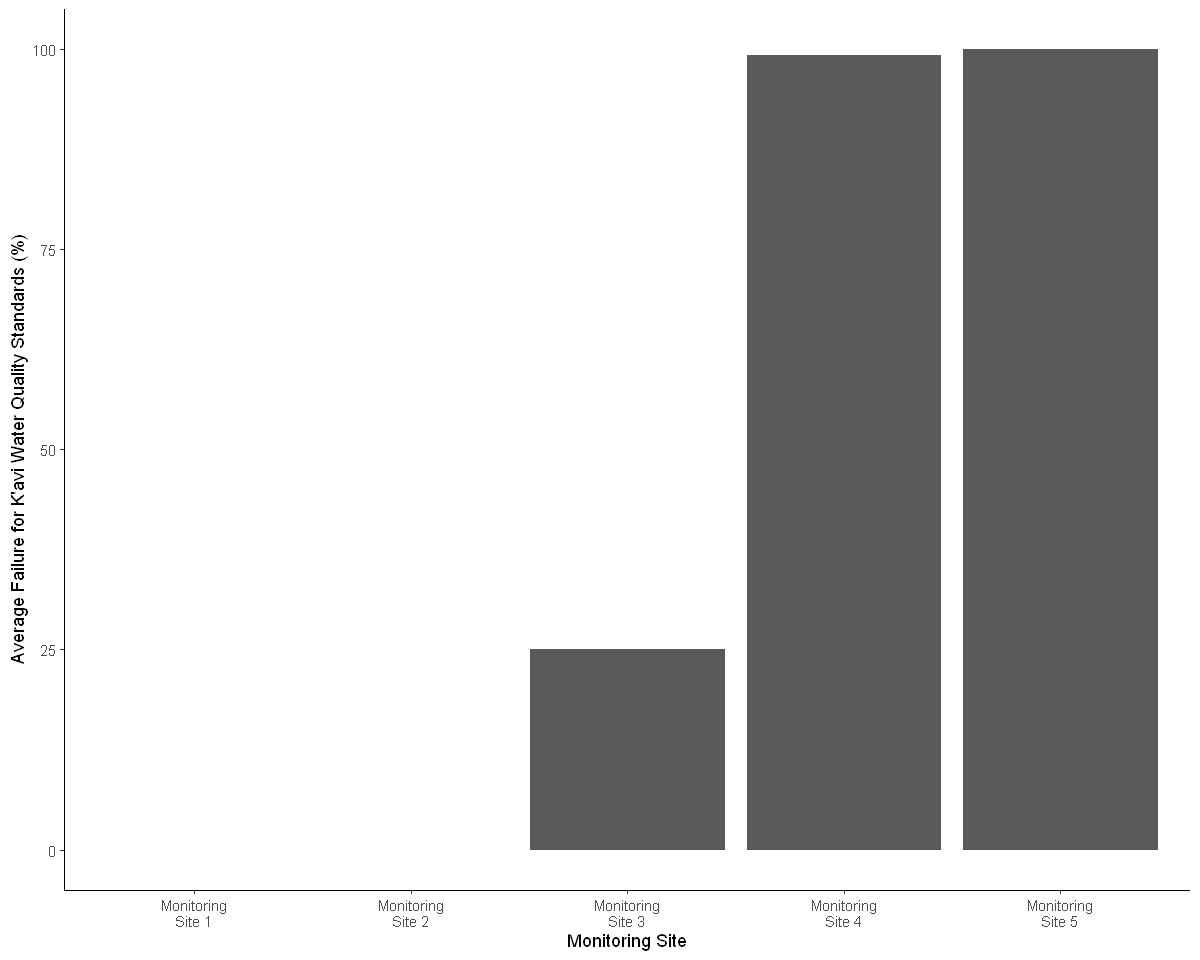

In [27]:
## visualize the data
rank_sum %>%
  ggplot(aes(x = sample_location, y = average_pass)) +
  geom_col() +
  xlab("Monitoring Site") +
  ylab("Average Failure for K'avi Water Quality Standards (%)") +
  # wrap the monitoring site names so that the text doesn't overlap
  scale_x_discrete(labels = function(x) str_wrap(x, width = 10)) +
  theme_classic()

### Visualize the ranked quality with TEK survey

The above plot shows us the average failure across all water standards by site, but doesn't show us which water standards are the highest percentages or which monitoring sites have a higher TEK ranking.

What if we want to visualize multiple variables at once? we can do this by assigning variables to shapes and colors. 

First, we are joining our dataframes from the TEK survey (`tek_sum`) and the ranked summary (`rank_sum`), and using `pivot_longer()` to condense the percentages to a single column. This gives us a data frame with variables:
- `sample_location`: monitoring sites
- `site`: cultural practice that occurs at each sample location
- `mean_tek`: ranking from survey 1-5
- `name`: name of bacteria or nutrient variable
- `value`: percent of tests that passed for clean

Between these variables, there are 3 categories, and 2 continuous variables. Consider how to plot these different variables, what type of geom is most useful, and where to place the different categories. [See different geoms here](https://ggplot2.tidyverse.org/reference/).

In [23]:
## join the ranked summary with tek survey summary 
rank_sum_tek <- inner_join(rank_sum, tek_sum, by='sample_location')  %>% 
  select(sample_location, mean_tek, site, ecoli_percent, tot_col_percent, nit_percent, phos_percent, sample_location) %>% 
  pivot_longer(c(ecoli_percent, tot_col_percent, nit_percent, phos_percent))

head(rank_sum_tek)


sample_location,mean_tek,site,name,value
<chr>,<dbl>,<chr>,<chr>,<dbl>
Monitoring Site 1,2.00,Ceremony.Site,ecoli_percent,0
Monitoring Site 1,2.00,Ceremony.Site,tot_col_percent,0
Monitoring Site 1,2.00,Ceremony.Site,nit_percent,0
Monitoring Site 1,2.00,Ceremony.Site,phos_percent,0
Monitoring Site 2,3.75,Medicinal.Food.Site,ecoli_percent,0
Monitoring Site 2,3.75,Medicinal.Food.Site,tot_col_percent,0


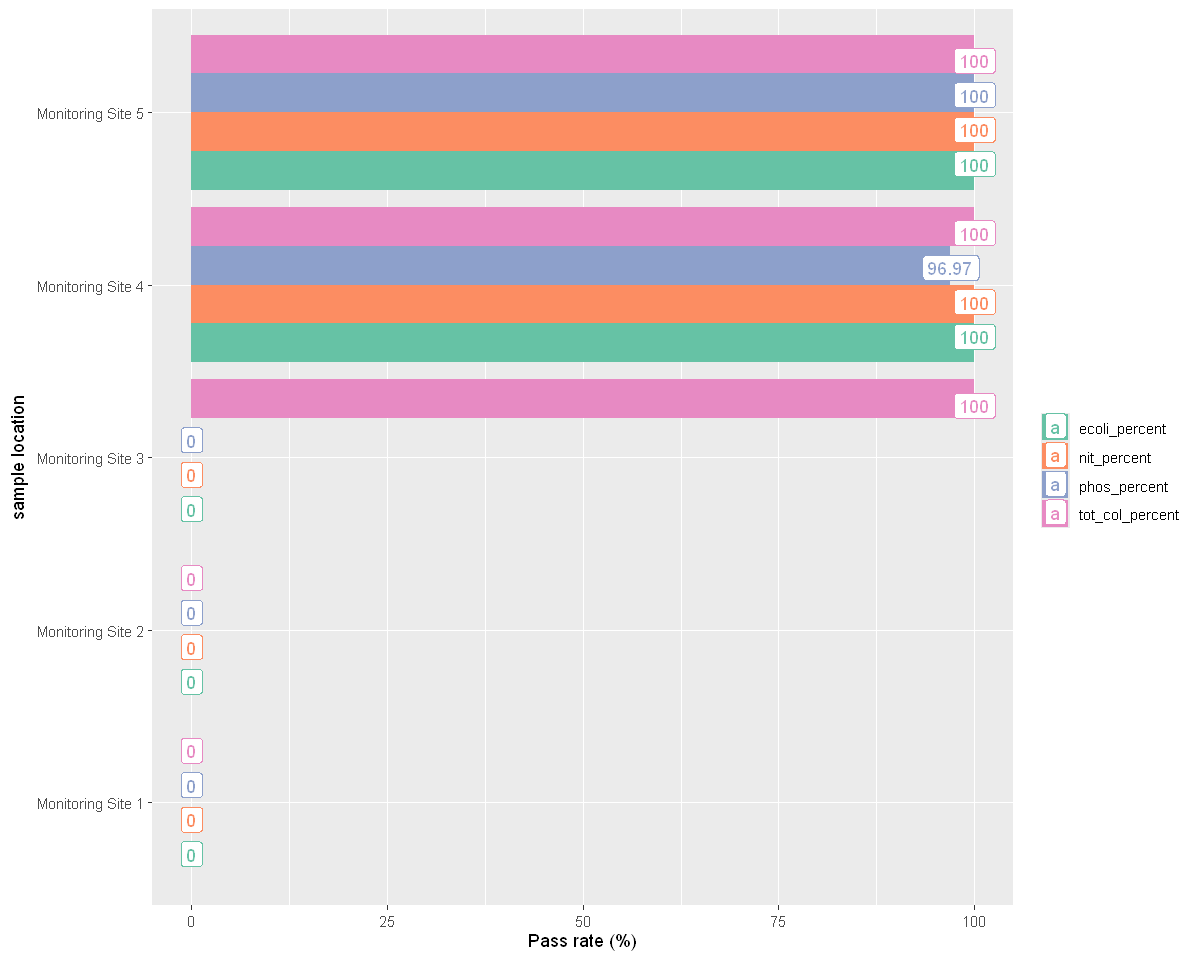

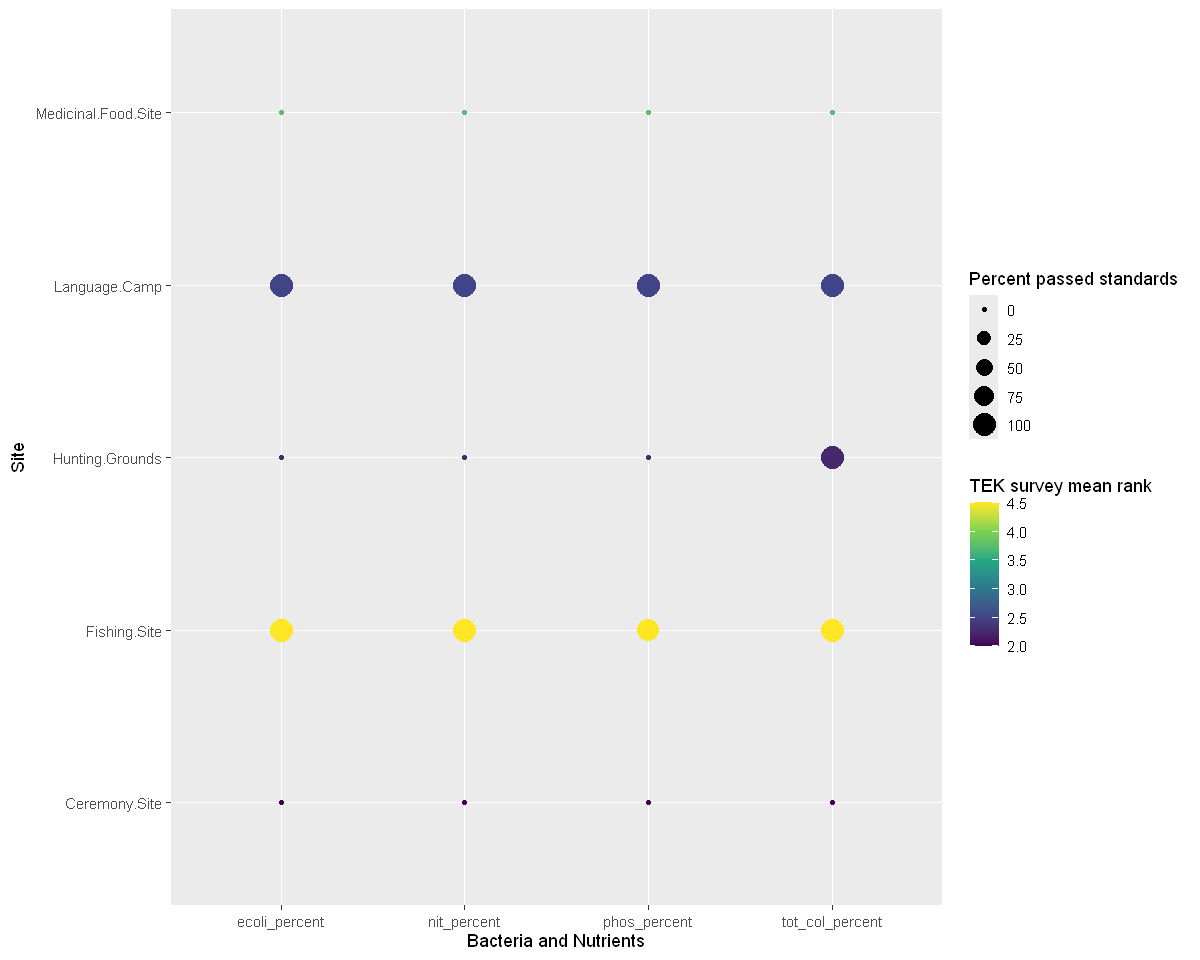

In [24]:
## visualize each location percent by water quality measure
rank_sum_tek %>% 
  ggplot(aes(x=sample_location, y=value, fill=name)) + 
  geom_col(position='dodge') +
  geom_label(aes(label=round(value,2), col=name), fill="white", position = position_dodge(width = 0.8)) +
  labs(x="sample location", y="Pass rate (%)", fill="", col="") +
  coord_flip() +
  scale_fill_brewer(palette="Set2") + scale_color_brewer(palette="Set2")

# visualize multiple categorical variables 
rank_sum_tek %>% 
  ggplot(aes(x=name, y=site, size=value, col=mean_tek)) +
  geom_count() +
  labs(x="Bacteria and Nutrients", y="Site", size="Percent passed standards", col="TEK survey mean rank") +
  scale_color_viridis_c() 

## Part 4 Recap 

At this part, we have gone through the entire process of loading data, exploring, summarizing, and visualizing, this time with measurements of bacteria and nutrients at each sample location. The steps included:

- manipulated data frame using `mutate()`, `select()`, `inner_join()`, `pivot_longer()`
- summarizing data by Sample Location using `group_by()` and `summarize()`
- another application of `ifelse()` function
- more visualization with ggplot